In [2]:
import pandas as pd
import numpy as np


## Data preparation

In [3]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
df = pd.read_csv(data)
df
# pd.read_csv('data.csv')

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


In [4]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [5]:
# Normalize column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [6]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [7]:
# To check the data types of each column in the DataFrame
df.dtypes
df['engine_fuel_type'].value_counts()


engine_fuel_type
regular unleaded                                7172
premium unleaded (required)                     2009
premium unleaded (recommended)                  1523
flex-fuel (unleaded/E85)                         899
diesel                                           154
electric                                          66
flex-fuel (premium unleaded required/E85)         54
flex-fuel (premium unleaded recommended/E85)      26
flex-fuel (unleaded/natural gas)                   6
natural gas                                        2
Name: count, dtype: int64

In [8]:
# To select only the columns with string data types
df.dtypes == 'str'
# To get the index (column names) of the columns with string data types
strings = list(df.dtypes[df.dtypes == 'str'].index)


In [9]:
# To loop through the list of string columns and normalize their values by converting them to lowercase and replacing spaces with underscores
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')




In [10]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

## Exploratory data analysis

In [11]:
# To find the unique values of each string column in the DataFrame
for col in strings:
    print(col)  # to print the name of the column
    print (df[col].unique()[0:5])  # print first 5 unique values of each string column
    print (df[col].nunique())  # print the number of unique values in each string column
    print () # To print a blank line between each column's output

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-performance',
                                'luxury',
                           'performance']
Length: 5, dtype: str
71

vehicle_size
<StringArray>
['compac

Price distribution

In [12]:
# to visualize the distribution of the target variable (price) using a histogram
import matplotlib.pyplot as plt # to import the matplotlib library for data visualization
import seaborn as sns # To import the seaborn library for data visualization

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

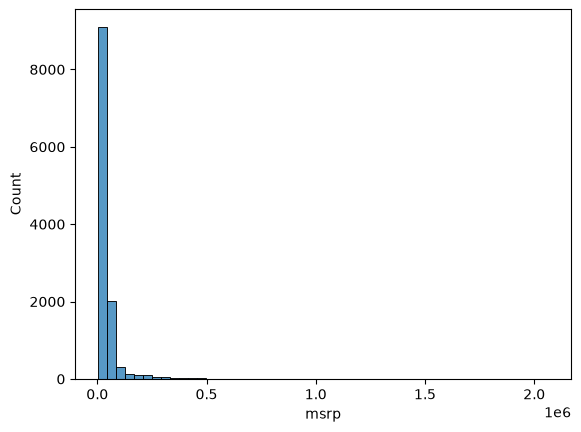

In [13]:
#to show the histogram of the target variable (price)
sns.histplot(df.msrp, bins=50)#sns is a data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics. The histplot() function is used to create a histogram of the specified data, in this case, the 'msrp' column of the DataFrame df. The bins parameter specifies the number of bins to use for the histogram, which determines how the data is grouped into intervals. In this case, 50 bins are used to create the histogram.
# bins are the intervals that the data is divided into for the histogram. The more bins you have, the more detailed the histogram will be, but it may also become more difficult to interpret. The fewer bins you have, the less detailed the histogram will be, but it may be easier to interpret. In this case, 50 bins are used to create a balance between detail and interpretability.

<Axes: xlabel='msrp', ylabel='Count'>

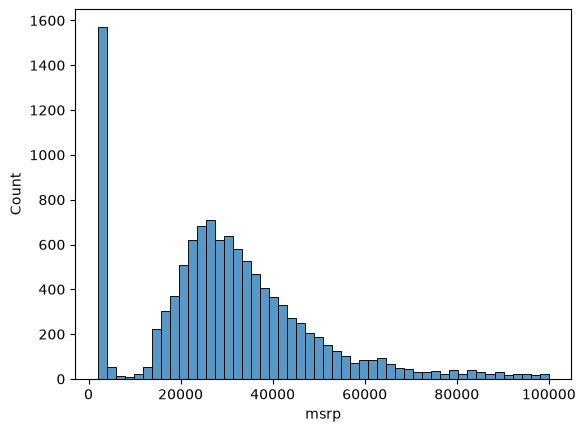

In [14]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50) #lets filter the data to only include prices less than 100,000 and create a histogram with 50 bins. This will help us visualize the distribution of prices in a more focused range, as extreme values can skew the histogram and make it difficult to interpret the data.


In [15]:
#The long tail in the previous chart is confusing to our module , so we need to minimze and get rede 
np.log1p([0 , 1 , 10 , 1000 , 10000 ])

array([0.        , 0.69314718, 2.39789527, 6.90875478, 9.21044037])

In [16]:
np.log([0+1 , 1 + 1,10 + 1, 1000 + 1 , 10000 + 1 ]) # It will bting high values and make them lower , and we 1 to each intercal to include

array([0.        , 0.69314718, 2.39789527, 6.90875478, 9.21044037])

In [17]:
# we apply the previous formula to our data price 
price_logs = np.log1p(df.msrp)
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

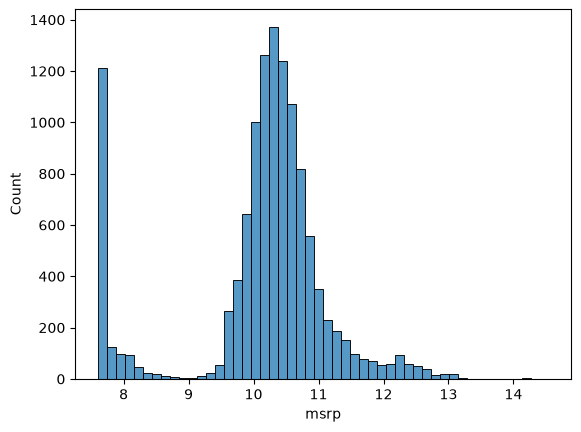

In [18]:
sns.histplot(price_logs, bins=50)

Missing Value

In [19]:
# To show the sum of mising values in our data for each column , so before training our modue we need to do something abot it 
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## Setting up the validation framework

In [20]:
# We will split data into training and validation sets using the train_test_split function from scikit-learn. We will use 80% of the data for training and 20% for validation. We will also set a random seed for reproducibility.
n = len(df) # To know the length of the data frame
len(df) * 0.6 # To know the length of the training set
len(df) * 0.2 # To know the length of the validation set  
len(df) * 0.2 # To know the length of the test set  

n_val = int(n * 0.2) # To calculate the length of the validation set
n_test = int(n * 0.2) # To calculate the length of the test set
n_train = int(n * 0.6) # To calculate the length of the training set

In [21]:
n , n_val + n_test + n_train # The resuls is not the same because of the rounding of the numbers when we convert them to integers. The sum of n_val, n_test, and n_train may not equal n due to this rounding. To ensure that the sum of the lengths of the training, validation, and test sets equals the total length of the data frame, we can adjust the lengths of the validation and test sets accordingly. For example, we can set n_val to be equal to n - n_train - n_test, which will ensure that the sum of the lengths of the three sets equals n.

(11914, 11912)

In [22]:
n_train = n - n_val - n_test # To adjust the length of the training set to ensure that the sum of the lengths of the training, validation, and test sets equals the total length of the data frame.

In [23]:
n_val , n_test , n_train , n

(2382, 2382, 7150, 11914)

In [24]:
#To take part of the data frame for training, validation, and testing sets, we can use the iloc method to select rows based on their integer index positions. We can use the calculated lengths of the training, validation, and test sets to slice the DataFrame accordingly.
df_val = df.iloc[:n_val, :] # To select the first n_val rows of the DataFrame for the validation set
df_test = df.iloc[n_val:n_val+n_test, :] # To select the next n_test rows of the DataFrame for the test set
df_train = df.iloc[n_val+n_test:, :] # To select the remaining rows of the DataFrame for the training set

In [25]:
#Shuffling the data is important to ensure that the training, validation, and test sets are representative of the overall dataset. This helps to prevent any bias that may arise from the order of the data. We can use the sample method from pandas to shuffle the DataFrame before splitting it into training, validation, and test sets. We can also set a random seed for reproducibility.
idx = np.arange (n) # To create an array of integers from 0 to n-1, which will be used as indices to shuffle the DataFrame.
np.random.seed(2) # To set a random seed for reproducibility, which ensures that the same random numbers are generated each time the code is run. This is important for reproducibility of results, especially when shuffling the data. 
np.random.shuffle(idx) # To shuffle the array of indices randomly, which will be used to shuffle the DataFrame.

In [26]:
df_train = df.iloc[idx[:n_train]] #It's better to start with training set and then validation and test sets, so we can use the remaining data for validation and test sets. This way, we can ensure that the training set is representative of the overall dataset and that the validation and test sets are also representative of the overall dataset.
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]


In [27]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [28]:
len(df_train) , len(df_val) , len(df_test)

(7150, 2382, 2382)

In [29]:
df_train = df_train.reset_index(drop=True) # To reset the index of the training set DataFrame and drop the old index column. This is important because we want to have a clean index for our training set, which will make it easier to work with and avoid any confusion when accessing rows by index.
df_val = df_val.reset_index(drop=True ) # To reset the index of the validation set DataFrame and drop the old index column. This is important because we want to have a clean index for our validation set, which will make it easier to work with and avoid any confusion when accessing rows by index.
df_test = df_test.reset_index(drop=True) # To reset the index of the test set DataFrame and drop the old index column. This is important because we want to have a clean index


# It will run in jupyter notebook


# df_train = df.iloc[idx[:n_train]].copy()
# df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
# df_test = df.iloc[idx[n_train + n_val:]].copy()

# df_train.reset_index(drop=True, inplace=True)
# df_val.reset_index(drop=True, inplace=True)
# df_test.reset_index(drop=True, inplace=True)

df_train



,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


In [30]:
y_train = np.log1p(df_train.msrp.values) #To apply the log transformation to the 'msrp' column of the training set DataFrame. The log transformation is used to reduce the skewness of the data and make it more normally distributed, which can improve the performance of some machine learning algorithms. The np.log1p() function is used to compute the natural logarithm of 1 plus the input array, which is useful for handling zero values in the data.
y_val = np.log1p(df_val.msrp.values) #To apply the log transformation to the 'msrp' column of the validation set DataFrame. The log transformation is used to reduce the skewness of the data and make it more normally distributed, which can improve the performance of some machine learning algorithms. The np.log1p() function is used to compute the natural logarithm of 1 plus the input array, which is useful for handling zero values in the data.
y_test = np.log1p(df_test.msrp.values) #To apply the log transformation to the 'msrp' column of the test set DataFrame. The log transformation is used to reduce the skewness of the data and make it more normally distributed, which can improve the performance of some machine learning algorithms. The np.log1p() function is used to compute the natural logarithm of 1 plus the input array, which is useful for handling zero values in the data.

In [31]:
del df_train['msrp'] # To delete the 'msrp' column from the training set DataFrame. This is done because we have already applied the log transformation to this column and we don't need it anymore for training our model.
del df_val['msrp'] # To delete the 'msrp' column from the validation set DataFrame. This is done because we have already applied the log transformation to this column and we don't need it anymore for training our model.
del df_test['msrp'] # To delete the 'msrp' column from the test

## Linear regression

In [32]:

df_train.iloc[10] # Let's look at training set row 10 to see what the data looks like after preprocessing. This will help us understand the structure of the data and the types of features we have available for training our model.


make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [33]:
#Let's take most important features and put them in list as feature matrix ( Xi= [ 453 ,11 , 86  ])
# engine_hp , city_mpg , popularity 
xi = [453 , 11 , 86  ]

In [34]:
# For example let's put initial values for the weights and bias term of the linear regression model. The weights represent the importance of each feature in predicting the target variable (price), while the bias term allows the model to make predictions that are not constrained to pass through the origin (0,0). These initial values can be adjusted during training to improve the accuracy of the model.
w0 = 7.17 # initial bias, bias term for the linear regression model. The bias term allows the model to make predictions that are not constrained to pass through the origin (0,0) and can help improve the accuracy of the model by allowing it to better fit the data.
w = [0.01, 0.04, 0.002] # weights for each feature (engine_hp, city_mpg, popularity)

In [35]:
# g(X) = Y > g is model which is Liear regrssion model , X is feature matrix , Y is the target which is the price in this project 
# g(xi) = yi

def g(xi):
    #do something with xi to get yi > implement the logic to compute the predicted price based on the input features xi. The output yi would be the predicted price for the car represented by the feature vector xi.
    return 10000 # ( retusr yi ) return a constant value for now, but in practice, this function would contain the logic to compute the predicted price based on the input features xi. The output yi would be the predicted price for the car represented by the feature vector xi.

In [36]:
g(xi)

10000

In [37]:
# The formula to apply linear regression is g(xi) = w1 * x1 + w2 * x2 + w3 * x3 + b, where w1, w2, and w3 are the weights for each feature (engine_hp, city_mpg, popularity), and b is the bias term. The goal of training the linear regression model is to find the optimal values for these weights and bias that minimize the difference between the predicted prices and the actual prices in the training set.
# g(xi) = b + sum(wi * xi) for i in range(len(xi))

def linear_regression_model(xi):

    n = len(xi) # To get the number of features in the input feature vector xi. This will be used to iterate over the features and compute the weighted sum of the input features.

    pred = w0 # To initialize the predicted price variable with the bias term b. This will be used to accumulate the weighted sum of the input features.

    for j in range(n): # To iterate over the features in the input feature vector xi. The range(n) function generates a sequence of integers from 0 to n-1, which will be used as indices to access the elements of the input feature vector xi and the weights vector w.
        pred = pred + w[j] * xi[j] # To compute the weighted sum of the input features. For each feature j, we multiply the weight w[j] by the corresponding input feature xi[j] and add it to the predicted price variable pred.

    #do something with xi to get yi > implement the logic to compute the predicted price based on the input features xi. The output yi would be the predicted price for the car represented by the feature vector xi.
    return pred # ( retusr yi ) return a constant value for now, but in practice, this function would contain the logic to compute the predicted price based on the input features xi. The output yi would be the predicted price for the car represented by the feature vector xi.

In [38]:
linear_regression_model(xi) # to apply the linear regression model to the input feature vector xi and compute the predicted price for the car represented by the feature vector xi. The output of this function will be the predicted price based on the current values of the weights and bias term.

12.312

In [39]:
np.exp(linear_regression_model(xi)) - 1 # To apply the exponential function to the predicted price returned by the linear regression model and subtract 1. This is done to reverse the log transformation that was applied to the target variable (price) earlier in the code. The np.exp() function computes the exponential of the input array, which is used to transform the predicted price back to its original scale. Subtracting 1 is necessary because we added 1 to the target variable before applying  the log transformation.

np.float64(222347.2221101062)

In [40]:
np.log1p(np.exp(linear_regression_model(xi)) - 1) # To apply the log transformation to the predicted price returned by the linear regression model after reversing the previous log transformation. This is done to ensure that the predicted price is on the same scale as the target variable (price) in the training set. The np.log1p() function computes the natural logarithm of 1 plus the input array, which is useful for handling zero values in the data.

np.float64(12.312)

# Linear regression vector form

In [41]:
def dot (xi , w): # g(xi) = b + sum(xi * w) = b + (Xi)t * w
    # To compute the dot product of the input feature vector xi and the weights vector w. The dot product is a mathematical operation that takes two equal-length sequences of numbers (in this case, the input feature vector xi and the weights vector w) and returns a single number that represents the sum of the products of the corresponding elements of the two sequences. This operation is used in linear regression to compute the predicted price based on the input features and their corresponding weights.
    n = len(xi) 

    pred = 0.0  # predicted variable to accumulate the dot product of the input feature vector xi and the weights vector w. This variable will be used to store the sum of the products of the corresponding elements of xi and w.

    for j in range(n): # To iterate over the features in the input feature vector xi. The range(n) function generates a sequence of integers from 0 to n-1, which will be used as indices to access the elements of the input feature vector xi and the weights vector w.
        pred = pred +  xi[j] * w[j] # To compute the product of the corresponding elements of xi and w and add it to the result variable res. This is done for each feature j in the input feature vector xi.

    return pred # To return the final result of the dot product computation, which is the sum of the products of the corresponding elements of xi and w. This value represents the predicted price for the car represented by the input feature vector xi based on the current values of the weights vector w.

In [42]:
w_new = [w0] + w # where w0 is the bias term and w is the weights vector. This creates a new list w_new that contains the bias term as the first element followed by the weights for each feature. This is done to simplify the computation of the predicted price in the linear regression model, as we can now compute the dot product of the input feature vector xi and the weights vector w_new, which includes the bias term.
w_new

[7.17, 0.01, 0.04, 0.002]

In [43]:
def linear_regression_model(xi):
    xi = [1] + xi # To add a bias term of 1 to the input feature vector xi. This is done to account for the bias term in the linear regression model, which allows the model to make predictions that are not constrained to pass through the origin (0,0). By adding a bias term of 1 to the input feature vector, we can compute the dot product of the input feature vector and the weights vector, which includes the bias term as the first element.
    return w0 + dot(xi, w_new) # To compute the predicted price for the car represented by the input feature vector xi based on the current values of the weights vector w and the bias term w0. The dot() function is used to compute the dot product of the input feature vector xi and the weights vector w, which is then added to the bias term w0 to obtain the final predicted price.   

In [44]:
linear_regression_model(xi) # to apply the linear regression model to the input feature vector xi and compute the predicted price for the car represented by the feature vector xi. The output of this function will be the predicted price based on the current values of the weights and bias term.

19.482

In [45]:
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [46]:
x1 = [1,148,24,1385] # To create a new input feature vector x1 that includes a bias term of 1 as the first element, followed by the values of the three features (engine_hp, city_mpg, popularity) for a specific car. This input feature vector will be used to compute the predicted price for this car using the linear regression model.
x2 = [1,132 , 25 , 2031] # To create a new input feature vector x2 that includes a bias term of 1 as the first element, followed by the values of the three features (engine_hp, city_mpg, popularity) for another specific car. This input feature vector will be used to compute the predicted price for this car using the linear regression model.
x3 = [1, 453 , 11 , 86] # To create a new input feature vector x3 that includes a bias term of 1 as the first element, followed by the values of the three features (engine_hp, city_mpg, popularity) for another specific car. This input feature vector will be used to compute the predicted price for this car using the linear regression model.

X = [x1, x2, x3] # To create a list of input feature vectors X that contains the three input feature vectors x1, x2, and x3. This list will be used to compute the predicted prices for each of the three cars represented by the input feature vectors using the linear regression model.
X = np.array(X) # To convert the list of input feature vectors X into a NumPy array. This is done to facilitate mathematical operations and computations on the input feature vectors, as NumPy provides efficient array operations and functions for numerical computations. The resulting NumPy array will have a shape of (3, 4), where 3 is the number of input feature vectors and 4 is the number of features (including the bias term).
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [47]:
def linear_regression_model(xi):
    return X.dot((w_new))

In [48]:
linear_regression_model(X) # to apply the linear regression model to the input feature matrix X and compute the predicted prices for each of the three cars represented by the input feature vectors. The output of this function will be an array of predicted prices based on the current values of the weights and bias term.    

array([12.38 , 13.552, 12.312])

## Training Linear Regression Model

In [49]:
def train_linear_regression_model(X,y):
    # To implement the training process for the linear regression model. This function takes in the input feature matrix x and the target variable y (which is the log-transformed price) and updates the weights and bias term of the model to minimize the difference between the predicted prices and the actual prices in the training set. The training process typically involves using an optimization algorithm (such as gradient descent) to iteratively adjust the weights and bias term based on the computed gradients of the loss function with respect to these parameters. The goal is to find the optimal values for the weights and bias that minimize the loss function, which measures how well the model fits the training data.
    pass # Placeholder for the implementation of the training process. This will be replaced with the actual code that performs the training of the linear regression model.

In [50]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]

X = np.array(X) # To convert the list of input feature vectors X into a NumPy array. This is done to facilitate mathematical operations and computations on the input feature vectors, as NumPy provides efficient array operations and functions for numerical computations. The resulting NumPy array will have a shape of (9, 3), where 9 is the number of input feature vectors and 3 is the number of features (engine_hp, city_mpg, popularity).
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [51]:
ones = np.ones(X.shape[0]) #  To create a NumPy array of ones with a length of 9. This array will be used to add a bias term of 1 to each input feature vector in the input feature matrix X. By adding a bias term of 1 to each input feature vector, we can compute the dot product of the input feature matrix and the weights vector, which includes the bias term as the first element. The resulting array will have a shape of (9,), where 9 is the number of input feature vectors.
ones



array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [52]:
X = np.column_stack([ones , X]) # To include ones with the feature matrix 
X 

array([[1.000e+00, 1.480e+02, 2.400e+01, 1.385e+03],
       [1.000e+00, 1.320e+02, 2.500e+01, 2.031e+03],
       [1.000e+00, 4.530e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 1.580e+02, 2.400e+01, 1.850e+02],
       [1.000e+00, 1.720e+02, 2.500e+01, 2.010e+02],
       [1.000e+00, 4.130e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 3.800e+01, 5.400e+01, 1.850e+02],
       [1.000e+00, 1.420e+02, 2.500e+01, 4.310e+02],
       [1.000e+00, 4.530e+02, 3.100e+01, 8.600e+01]])

In [53]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000] # To create a list of target variable values y that contains the log-transformed prices for each of the nine cars represented by the input feature vectors in X. This list will be used to train the linear regression model and update the weights and bias term to minimize the difference between the predicted prices and the actual prices in the training set.

In [54]:
XTX = X.T.dot(X) # To compute the dot product of the transpose of the input feature matrix X and the input feature matrix X itself. This operation is used in linear regression to compute the covariance matrix of the input features, which is used to estimate the optimal values for the weights and bias term of the model. The resulting matrix XTX will have a shape of (3, 3), where 3 is the number of features (engine_hp, city_mpg, popularity).
XTX

array([[9.000000e+00, 2.109000e+03, 2.300000e+02, 4.676000e+03],
       [2.109000e+03, 6.964710e+05, 4.411500e+04, 7.185400e+05],
       [2.300000e+02, 4.411500e+04, 7.146000e+03, 1.188030e+05],
       [4.676000e+03, 7.185400e+05, 1.188030e+05, 6.359986e+06]])

In [55]:
XTX_inv = np.linalg.inv(XTX) # To compute the inverse of the covariance matrix XTX. The inverse of a matrix is a mathematical operation that allows us to solve systems of linear equations and is used in linear regression to estimate the optimal values for the weights and bias term of the model. The resulting matrix will have the same shape as XTX, which is (3, 3).
XTX.dot(XTX_inv) # To compute the dot product of the covariance matrix XTX and its inverse XTX_inv. This operation is used to verify that the inverse has been computed correctly, as the dot product of a matrix and its inverse should yield the identity matrix. The resulting matrix will have a shape of (3, 3), where 3 is the number of features (engine_hp, city_mpg, popularity).


array([[ 1.00000000e+00, -1.95495204e-18,  6.28430684e-17,
         1.75822864e-18],
       [-9.06380006e-14,  1.00000000e+00,  6.18373354e-15,
         5.01606559e-17],
       [-1.90098479e-13,  7.34292862e-18,  1.00000000e+00,
         2.74699667e-17],
       [-3.38086980e-13, -7.69365108e-16,  1.45868899e-14,
         1.00000000e+00]])

In [56]:
w_full = XTX_inv.dot(X.T).dot(y)  # To find weights of our moded for the traing set  
w0 = w_full[0] # The bias which is usually the first elemen w0
w = w_full[1:]
w0 , w

(np.float64(25844.754055766753),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

In [57]:
def train_linear_regression(X, y): # We can put everything explained above in the fundction to be applied on our model
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones , X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    # XTX_inv = np.linalg.pinv(XTX) # To avoid the " linalg Singular matrix " error . To compute the pseudo-inverse of the covariance matrix XTX. The pseudo-inverse is a generalization of the inverse of a matrix that can be used when the matrix is not invertible (i.e., when it is singular or not square). In linear regression, the pseudo-inverse is used to estimate the optimal values for the weights and bias term of the model when the covariance matrix is not invertible. The resulting matrix will have the same shape as XTX, which is (3, 3).
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [58]:
train_linear_regression(X[:, 1:], y) # To apply the train_linear_regression function to the input feature matrix X (excluding the bias term) and the target variable y. This function will compute the optimal values for the weights and bias term of the linear regression model based on the training data. The output will be a tuple containing the bias term w0 and the weights vector w, which can be used to make predictions for new input feature vectors using the linear regression model.

(np.float64(25844.754055766753),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

## Car Price Baseline Model

In [59]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [60]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [61]:
# we take the most important numerical columns in the training set to be used in our model and put them in list
base = ['engine_hp','engine_cylinders' , 'highway_mpg' , 'city_mpg' , 'popularity' ]

df_train[base]

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,148.0,4.0,33,24,1385
1,132.0,4.0,32,25,2031
2,148.0,4.0,37,28,640
3,90.0,4.0,18,16,873
4,385.0,8.0,21,15,5657
...,...,...,...,...,...
7145,300.0,6.0,31,20,3916
7146,210.0,4.0,30,24,873
7147,285.0,6.0,22,17,549
7148,563.0,12.0,21,13,86


In [62]:
X_train = df_train[base].values # To extract the values of the selected numerical columns from the training set DataFrame and store them in a NumPy array. This array will be used as the input feature matrix for training the linear regression model. The resulting array will have a shape of (n_train, 5), where n_train is the number of rows in the training set and 5 is the number of selected numerical features.
X_train


array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]], shape=(7150, 5))

In [63]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

In [64]:
# If we apply the model , We will get nan values , due to the presence of missing values in the input feature matrix x_train. The linear regression model cannot handle missing values, so we need to preprocess the data to handle these missing values before training the model. This can be done by either removing rows with missing values or imputing the missing values with a suitable value (such as the mean or median of the column).
df_train[base].isnull().sum() # To check for missing values in the selected numerical columns of the training set DataFrame. This will help us identify any columns that may have missing values, which can affect the performance of the linear regression model. The output will be a Series object that shows the number of missing values for each selected numerical column.

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [65]:
df_train[base].fillna(0).isnull().sum() # To fill the missing values in the selected numerical columns of the training set DataFrame with 0. This is done to handle the missing values before training the linear regression model, as the model cannot handle missing values. By filling the missing values with 0, we can ensure that all input feature vectors have the same length and can be used to train the model. However, this approach may not be appropriate for all datasets and should be carefully considered based on the specific characteristics of the data.

engine_hp           0
engine_cylinders    0
highway_mpg         0
city_mpg            0
popularity          0
dtype: int64

In [66]:
X_train = df_train[base].fillna(0).values # To extract the values of the selected numerical columns from the training set DataFrame, fill any missing values with 0, and store them in a NumPy array. This array will be used as the input feature matrix for training the linear regression model. The resulting array will have a shape of (n_train, 5), where n_train is the number of rows in the training set and 5 is the number of selected numerical features.


In [67]:
w0 , w = train_linear_regression(X_train, y_train) # To apply the train_linear_regression function to the input feature matrix x_train and the target variable y_train. This function will compute the optimal values for the weights and bias term of the linear regression model based on the training data. The output will be a tuple containing the bias term w0 and the weights vector w, which can be used to make predictions for new input feature vectors using the linear regression model.
w

array([ 9.70589522e-03, -1.59103494e-01,  1.43792133e-02,  1.49441072e-02,
       -9.06908672e-06])

In [68]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

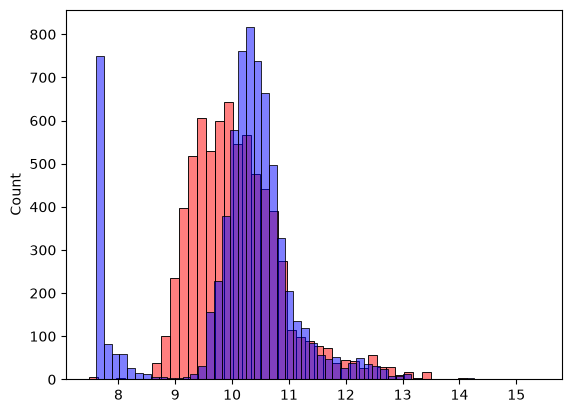

In [69]:
sns.histplot(y_pred , color = 'red' , alpha = 0.5 , bins = 50) # To create a histogram of the predicted prices y_pred using the seaborn library. The color parameter is set to 'red' to specify the color of the bars in the histogram, and the alpha parameter is set to 0.5 to make the bars semi-transparent. The bins parameter is set to 50 to specify the number of bins to use for the histogram, which determines how the data is grouped into intervals. This histogram will help visualize the distribution of the predicted prices based on the trained linear regression model.
sns.histplot(y_train , color = 'blue' , alpha = 0.5 , bins = 50) # To create a histogram of the actual prices y_train using the seaborn library. The color parameter is set to 'blue' to specify the color of the bars in the histogram, and the alpha parameter is set to 0.5 to make the bars semi-transparent. The bins parameter is set to 50 to specify the number of bins to use for the histogram, which determines how the data is grouped into intervals. This histogram will help visualize the distribution of the actual prices in the training set and compare it with the predicted prices from the trained linear regression model.

we trained the baseline model , we ploted predections and actual values. But we don't have way to quantify how bad the model is , so we find the RMSE 

## RMSE ( Root Mean Square Error )
statistical metric that measures the average magnitude of the errors between predicted values and actual observed values. 
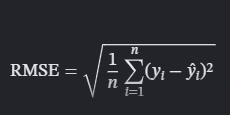
n is number of observations 


In [70]:
def rmse(y, y_pred): # To find the root mean squared error (RMSE) between the actual prices y and the predicted prices y_pred. The RMSE is a common metric used to evaluate the performance of regression models, as it measures the average magnitude of the errors between the predicted and actual values. A lower RMSE indicates better model performance.
    error = y - y_pred # error is the difference between the actual prices y and the predicted prices y_pred. This represents the residuals or errors of the model's predictions, which are used to compute the RMSE.
    se = error ** 2 # Sqrt of the squared errors. This is done to ensure that all errors are positive and to give more weight to larger errors, which can help identify areas where the model is performing poorly.
    mse = se.mean() # To compute the mean squared error (MSE) between the actual prices y and the predicted prices y_pred. The MSE is a common metric used to evaluate the performance of regression models, as it measures the average squared difference between the predicted and actual values. A lower MSE indicates better model performance.
    return np.sqrt(mse) # Return the root mean squared error (RMSE), which is the square root of the mean squared error.

In [71]:
rmse(y_train , y_pred) # To find the root mean squared error (RMSE) between the actual prices y_train and the predicted prices y_pred. This will give us an indication of how well the trained linear regression model is performing on the training set, with a lower RMSE indicating better model performance.

np.float64(0.7554192603920132)

## RMSE on Validation the Module

In [72]:
base = ['engine_hp','engine_cylinders' , 'highway_mpg' , 'city_mpg' , 'popularity' ]

X_train = df_train[base].fillna(0).values # To extract the values of the selected numerical columns from the training set DataFrame, fill any missing values with 0, and store them in a NumPy array. This array will be used as the input feature matrix for training the linear regression model. The resulting array will have a shape of (n_train, 5), where n_train is the number of rows in the training set and 5 is the number of selected numerical features.

w0 , w = train_linear_regression(X_train, y_train) # To apply the train_linear_regression function to the input feature matrix x_train and the target variable y_train. This function will compute the optimal values for the weights and bias term of the linear regression model based on the training data. The output will be a tuple containing the bias term w0 and the weights vector w, which can be used to make predictions for new input feature vectors using the linear regression model.

y_pred = w0 + X_train.dot(w)

In [73]:
def prepare_X(df): # To prepare the input feature matrix X from the given DataFrame df. This function takes in a DataFrame and extracts the values of the selected numerical columns, fills any missing values with 0, and returns a NumPy array that can be used as the input feature matrix for making predictions using the trained linear regression model.
    df_num = df[base]  # To define the list of selected numerical columns that will be used as features for the linear regression model.
    df_num = df_num.fillna(0)# To fill any missing values in the given DataFrame df with 0, and store them in a NumPy array. This array will be used as the input feature matrix for making predictions using the trained linear regression model.
    X = df_num.values # To extract the values of the selected numerical columns from the given DataFrame df, fill any missing values with 0, and store them in a NumPy array. This array will be used as the input feature matrix for making predictions using the trained linear regression model.
    return X # To return the prepared input feature matrix X that can be used for making predictions using the trained linear regression model.

In [74]:
def prepare_X(df):
    return df[base].fillna(0).values

X_train = prepare_X(df_train)

w0 , w = train_linear_regression(X_train, y_train) # To apply the train_linear_regression function to the prepared input feature matrix X_train and the target variable y_train. This function will compute the optimal values for the weights and bias term of the linear regression model based on the training data. The output will be a tuple containing the bias term w0 and the weights vector w, which can be used to make predictions for new input feature vectors using the trained linear regression model.

X_val = prepare_X(df_val) # To prepare the input feature matrix X_val from the validation set DataFrame df_val using the prepare_X function. This will extract the values of the selected numerical columns, fill any missing values with 0, and return a NumPy array that can be used as the input feature matrix for making predictions using the trained linear regression model.

y_pred = w0 + X_val.dot(w) # To compute the predicted prices y_pred for the validation set using the trained linear regression model. This is done by taking the dot product of the prepared input feature matrix X_val and the weights vector w, and adding the bias term w0. The resulting array y_pred will contain the predicted prices for each car in the validation set based on the trained model.

rmse(y_val , y_pred) # To find the root mean squared error (RMSE) between the actual prices y_val and the predicted prices y_pred for the validation set. This will give us an indication of how well the trained linear regression model is performing on the validation set, with a lower RMSE indicating better model performance.

np.float64(0.761653099130156)

## Feature Enginnering 
Will add more features to improve our model

In [75]:
df_train.year.max() # To find the maximum value of the 'year' column in the training set DataFrame df_train. This will give us an indication of the most recent year for which we have data in the training set, which can be useful for understanding the time range of the data and for making predictions for future years.

2017 - df_train.year # we want us this as feature in our model to predict the price of the car based on its age. By subtracting the year of the car from 2017, we can create a new feature that represents the age of the car in years. This feature can be used as an input to the linear regression model to help predict the price of the car based on its age, along with other features such as engine horsepower, city miles per gallon, and popularity.



0        9
1        5
2        1
3       26
4        0
        ..
7145     2
7146     2
7147     2
7148     3
7149     0
Name: year, Length: 7150, dtype: int64

In [76]:


# Lets use the the same of the previous validation moduled with some modification to include the age of the car as a feature in our model. We will create a new function prepare_X that takes in a DataFrame and extracts the values of the selected numerical columns, fills any missing values with 0, and returns a NumPy array that can be used as the input feature matrix for making predictions using the trained linear regression model. We will also create a new column 'age' in the given DataFrame that represents the age of the car in years, which will be used as an input to the linear regression model to help predict the price of the car based on its age, along with other features such as engine horsepower, city miles per gallon, and popularity.

def prepare_X(df): # To prepare the input feature matrix X from the given DataFrame df. This function takes in a DataFrame and extracts the values of the selected numerical columns, fills any missing values with 0, and returns a NumPy array that can be used as the input feature matrix for making predictions using the trained linear regression model.
    df = df.copy() # To create a copy of the given DataFrame df. This is done to avoid modifying the original DataFrame and to ensure that any changes made to the copy do not affect the original data. The copy will be used to create a new column 'age' that represents the age of the car in years, which will be used as an input to the linear regression model to help predict the price of the car based on its age, along with other features such as engine horsepower, city miles per gallon, and popularity.

    df['age'] = 2017 - df.year # To create a new column 'age' in the given DataFrame df that represents the age of the car in years. This is done by subtracting the 'year' column from 2017, which gives us the number of years since the car was manufactured. This new feature can be used as an input to the linear regression model to help predict the price of the car based on its age, along with other features such as engine horsepower, city miles per gallon, and popularity.
    features = base + ['age'] # To create a new list of features that includes the selected numerical columns from the base list and the newly created 'age' column. This list will be used to extract the values of the selected features from the given DataFrame df and prepare the input feature matrix X for making predictions using the trained linear regression model.

    df_num = df[features]  # To define the list of selected numerical columns that will be used as features for the linear regression model.
    df_num = df_num.fillna(0) # To fill any missing values with 0, and store them in a NumPy array. This array will be used as the input feature matrix for making predictions using the trained linear regression model.
    X = df_num.values # To extract the values of the selected numerical columns from the given DataFrame df, fill any missing values with 0, and store them in a NumPy array. This array will be used as the input feature matrix for making predictions using the trained linear regression model.
    return X # To return the prepared input feature matrix X that can be used for making predictions using the trained linear regression model.


In [77]:
# We can use it anoither way too 

# # Lets use the the same of the previous validation moduled with some modification to include the age of the car as a feature in our model. We will create a new function prepare_X that takes in a DataFrame and extracts the values of the selected numerical columns, fills any missing values with 0, and returns a NumPy array that can be used as the input feature matrix for making predictions using the trained linear regression model. We will also create a new column 'age' in the given DataFrame that represents the age of the car in years, which will be used as an input to the linear regression model to help predict the price of the car based on its age, along with other features such as engine horsepower, city miles per gallon, and popularity.

# def prepare_X(df):
    
#     features = base + ['age'] # To create a new list of features that includes the selected numerical columns from the base list and the newly created 'age' column. This list will be used to extract the values of the selected features from the given DataFrame df and prepare the input feature matrix X for making predictions using the trained linear regression model.

#     df_num = df.copy() # To create a copy of the given DataFrame df to avoid modifying the original DataFrame. This is done to ensure that any changes made to the copied DataFrame do not affect the original DataFrame, which may be used for other purposes in the code. The copied DataFrame will be used to prepare the input feature matrix X for making predictions using the trained linear regression model.

#     df_num['age'] = 2017 - df_num['year'] # To create a new column 'age' in the copied DataFrame df_num that represents the age of the car in years. This is done by subtracting the 'year' column from 2017, which gives us the number of years since the car was manufactured. This new feature can be used as an input to the linear regression model to help predict the price of the car based on its age, along with other features such as engine horsepower, city miles per gallon, and popularity.

#     return df_num[features].fillna(0).values # To extract the values of the selected numerical columns (including the newly created 'age' column) from the copied DataFrame df_num, fill any missing values with 0, and return a NumPy array that can be used as the input feature matrix for making predictions using the trained linear regression model. This ensures that all input feature vectors have the same length and can be used to train or evaluate the model effectively.


# X_train = prepare_X(df_train)

In [78]:
df_train.dtypes # what happened is we added new column which is age and it is of type int64 , so we have to check the types of the other columns to make sure they are all numerical and can be used as input features for the linear regression model. This will help us identify any columns that may need to be converted to numerical types or dropped from the input feature matrix before training the model.

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [79]:

df_train.columns # To check the column names of the training set DataFrame df_train. This will help us identify the names of the columns that are being used as input features for the linear regression model, as well as any other columns that may be present in the DataFrame. This information can be useful for understanding the structure of the data and for selecting the appropriate features for training the model.

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [80]:
X_train # we notice the last column is added which is the new feature " age" 

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]], shape=(7150, 5))

In [81]:
# Let's use it on the validation set

X_train = prepare_X(df_train)

w0 , w = train_linear_regression(X_train, y_train) # To apply the train_linear_regression function to the prepared input feature matrix X_train and the target variable y_train. This function will compute the optimal values for the weights and bias term of the linear regression model based on the training data. The output will be a tuple containing the bias term w0 and the weights vector w, which can be used to make predictions for new input feature vectors using the trained linear regression model.

X_val = prepare_X(df_val) # To prepare the input feature matrix X_val from the validation set DataFrame df_val using the prepare_X function. This will extract the values of the selected numerical columns, fill any missing values with 0, and return a NumPy array that can be used as the input feature matrix for making predictions using the trained linear regression model.

y_pred = w0 + X_val.dot(w) # To compute the predicted prices y_pred for the validation set using the trained linear regression model. This is done by taking the dot product of the prepared input feature matrix X_val and the weights vector w, and adding the bias term w0. The resulting array y_pred will contain the predicted prices for each car in the validation set based on the trained model.

rmse(y_val , y_pred) # To find the root mean squared error (RMSE) between the actual prices y_val and the predicted prices y_pred for the validation set. This will give us an indication of how well the trained linear regression model is performing on the validation set, with a lower RMSE indicating better model performance.

np.float64(0.5172055461058299)

We noticed our model imporved from rmse = 0.761653099130156 to rmse = 0.5172055461058299

Also we can see the difference when we plot the predections and actual values , but we will use validation set instead of training 

<Axes: ylabel='Count'>

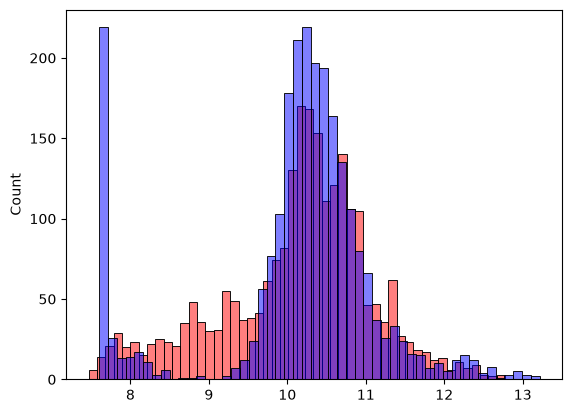

In [82]:
sns.histplot(y_pred , color = 'red' , alpha = 0.5 , bins = 50) # To create a histogram of the predicted prices y_pred using the seaborn library. The color parameter is set to 'red' to specify the color of the bars in the histogram, and the alpha parameter is set to 0.5 to make the bars semi-transparent. The bins parameter is set to 50 to specify the number of bins to use for the histogram, which determines how the data is grouped into intervals. This histogram will help visualize the distribution of the predicted prices based on the trained linear regression model.
sns.histplot(y_val , color = 'blue' , alpha = 0.5 , bins = 50) # To create a histogram of the actual prices y_train using the seaborn library. The color parameter is set to 'blue' to specify the color of the bars in the histogram, and the alpha parameter is set to 0.5 to make the bars semi-transparent. The bins parameter is set to 50 to specify the number of bins to use for the histogram, which determines how the data is grouped into intervals. This histogram will help visualize the distribution of the actual prices in the training set and compare it with the predicted prices from the trained linear regression model.

## Categorical Variables
* which are non numerical data type , or variables that are categories so these typically strings , not numbers 
like make , model , engine fuel type...etc 
* a data type that assigns an observation or individual to one of a fixed number of distinct groups or categories based on a qualitative property
* Nominal variables: Categories that have no specific or inherent rank or order, such as eye color (blue, green, brown) or gender (male, female, non-binary). 
* Ordinal variables: Categories that have a meaningful or natural rank and order, such as survey responses (dissatisfied, neutral, satisfied) or education level (high school, bachelor's, master's)
* Binary (dichotomous) variables: A special categorical variable that contains exactly two possible values, such as a yes/no or pass/fail question.


In [83]:
df_train.dtypes # To check the data types of the columns in the training set DataFrame df_train. This will help us identify any columns that may need to be converted to numerical types or dropped from the input feature matrix before training the model. It is important to ensure that all input features are numerical and can be used effectively in the linear regression model.

# Things that have type object or str are categorical features and cannot be used directly in the linear regression model. We need to either convert them to numerical types (e.g., using one-hot encoding) or drop them from the input feature matrix before training the model. 



make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [84]:
# But there one varialbe looks like numercial whihc is " Number of doors" , whih are categorcial 2,3,4 ... , but pandas considers them as numerical because they are stored as integers. However, since the number of doors is a categorical feature, we need to treat it as such and either convert it to a numerical type (e.g., using one-hot encoding) or drop it from the input feature matrix before training the model.
df_train["num_doors_2"] = (df_train.number_of_doors == 2 ).astype('int') # To create a new binary feature that indicates whether the number of doors for each car in the training set is equal to 2. This is done by comparing the 'number_of_doors' column in the training set DataFrame df_train to the value 2, which returns a boolean array where True indicates that the number of doors is equal to 2 and False indicates that it is not. The astype('int') method is then used to convert the boolean array to an integer array, where True is represented as 1 and False is represented as 0. This new binary feature can be used as an input to the linear regression model to help predict the price of the car based on whether it has 2 doors or not.
df_train["num_doors_3"] = (df_train.number_of_doors == 3 ).astype('int')
df_train["num_doors_4"] = (df_train.number_of_doors == 4 ).astype('int')

In [85]:
# or we can just write a loob 
for v in [2,3,4]:
    df_train[f"num_doors_%s" % v] = (df_train.number_of_doors == v).astype('int') # To create new binary features for each possible value of the 'number_of_doors' column in the training set DataFrame df_train. This is done by iterating over the list of possible values [2, 3, 4] and creating a new binary feature for each value that indicates whether the number of doors for each car in the training set is equal to that value. The astype('int') method is then used to convert the boolean array to an integer array, where True is represented as 1 and False is represented as 0. These new binary features can be used as inputs to the linear regression model to help predict the price of the car based on the number of doors it has.

In [86]:
# del df_train['num_doors_%s'] # To delete the 'num_doors_2' column from the training set DataFrame df_train. This is done to remove the binary feature that indicates whether the number of doors for each car in the training set is equal to 2, as it may not be necessary for the linear regression model or may be redundant with other features. By deleting this column, we can simplify the input feature matrix and potentially improve the performance of the model.

In [87]:


# Lets use the the same of the previous validation moduled with some modification to include the age of the car as a feature in our model. We will create a new function prepare_X that takes in a DataFrame and extracts the values of the selected numerical columns, fills any missing values with 0, and returns a NumPy array that can be used as the input feature matrix for making predictions using the trained linear regression model. We will also create a new column 'age' in the given DataFrame that represents the age of the car in years, which will be used as an input to the linear regression model to help predict the price of the car based on its age, along with other features such as engine horsepower, city miles per gallon, and popularity.

def prepare_X(df): # To prepare the input feature matrix X from the given DataFrame df. This function takes in a DataFrame and extracts the values of the selected numerical columns, fills any missing values with 0, and returns a NumPy array that can be used as the input feature matrix for making predictions using the trained linear regression model.
    df = df.copy() # To create a copy of the given DataFrame df. This is done to avoid modifying the original DataFrame and to ensure that any changes made to the copy do not affect the original data. The copy will be used to create a new column 'age' that represents the age of the car in years, which will be used as an input to the linear regression model to help predict the price of the car based on its age, along with other features such as engine horsepower, city miles per gallon, and popularity.
    features = base.copy() # To create a copy of the list of selected numerical columns from the base list. This is done to avoid modifying the original base list and to ensure that any changes made to the copied list do not affect the original list. The copied list will be used to define the features that will be extracted from the given DataFrame df and used as inputs to the linear regression model.
    
    df['age'] = 2017 - df.year # To create a new column 'age' in the given DataFrame df that represents the age of the car in years. This is done by subtracting the 'year' column from 2017, which gives us the number of years since the car was manufactured. This new feature can be used as an input to the linear regression model to help predict the price of the car based on its age, along with other features such as engine horsepower, city miles per gallon, and popularity.
    features.append('age') # To add the newly created 'age' column to the list of features that will be used to extract the values from the given DataFrame df and prepare the input feature matrix X for making predictions using the trained linear regression model.
    
    for v in [2,3,4]:
        df[f"num_doors_%s" % v] = (df_train.number_of_doors == v).astype('int') 
        features.append(f"num_doors_%s" % v) # To create new binary features for each possible value of the 'number_of_doors' column in the training set DataFrame df_train. This is done by iterating over the list of possible values [2, 3, 4] and creating a new binary feature for each value that indicates whether the number of doors for each car in the training set is equal to that value. The astype('int') method is then used to convert the boolean array to an integer array, where True is represented as 1 and False is represented as 0. These new binary features are then appended to the list of features that will be used to extract the values from the given DataFrame df and prepare the input feature matrix X for making predictions using the trained linear regression model.
    
    df_num = df[features]  # To define the list of selected numerical columns that will be used as features for the linear regression model.
    df_num = df_num.fillna(0) # To fill any missing values with 0, and store them in a NumPy array. This array will be used as the input feature matrix for making predictions using the trained linear regression model.
    X = df_num.values # To extract the values of the selected numerical columns from the given DataFrame df, fill any missing values with 0, and store them in a NumPy array. This array will be used as the input feature matrix for making predictions using the trained linear regression model.
    return X # To return the prepared input feature matrix X that can be used for making predictions using the trained linear regression model.


In [88]:
prepare_X(df_train)

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [285.,   6.,  22., ...,   0.,   0.,   1.],
       [563.,  12.,  21., ...,   0.,   0.,   1.],
       [200.,   4.,  31., ...,   0.,   0.,   1.]], shape=(7150, 9))

In [89]:
# Let's use it on the validation set

X_train = prepare_X(df_train)

w0 , w = train_linear_regression(X_train, y_train) # To apply the train_linear_regression function to the prepared input feature matrix X_train and the target variable y_train. This function will compute the optimal values for the weights and bias term of the linear regression model based on the training data. The output will be a tuple containing the bias term w0 and the weights vector w, which can be used to make predictions for new input feature vectors using the trained linear regression model.

X_val = prepare_X(df_val) # To prepare the input feature matrix X_val from the validation set DataFrame df_val using the prepare_X function. This will extract the values of the selected numerical columns, fill any missing values with 0, and return a NumPy array that can be used as the input feature matrix for making predictions using the trained linear regression model.

y_pred = w0 + X_val.dot(w) # To compute the predicted prices y_pred for the validation set using the trained linear regression model. This is done by taking the dot product of the prepared input feature matrix X_val and the weights vector w, and adding the bias term w0. The resulting array y_pred will contain the predicted prices for each car in the validation set based on the trained model.

rmse(y_val , y_pred) # To find the root mean squared error (RMSE) between the actual prices y_val and the predicted prices y_pred for the validation set. This will give us an indication of how well the trained linear regression model is performing on the validation set, with a lower RMSE indicating better model performance.

np.float64(0.5186588617185612)

In [90]:
# We noticed the imporvemnet after 'number of doord' is Neglectable or not useful , so let's try with "make"
df['make'].unique() # To find the unique values in the 'make' column of the DataFrame df. This will give us an indication of the different car manufacturers that are present in the dataset, which can be useful for understanding the diversity of the data and for selecting appropriate features for training the linear regression model.
df['make'].value_counts().head()  # To count the occurrences of each unique value in the 'make' column of the DataFrame df. This will give us an indication of the distribution of car manufacturers in the dataset, which can be useful for understanding the diversity of the data and for selecting appropriate features for training the linear regression model.
df['make'].value_counts().head().index # To retrieve the index (i.e., the unique values) of the top 5 most common car manufacturers in the 'make' column of the DataFrame df. This will give us an indication of the most popular car manufacturers in the dataset, which can be useful for understanding the diversity of the data and for selecting appropriate features for training the linear regression model.
makes = list (df['make'].value_counts().head().index) # To convert the index of the top 5 most common car manufacturers in the 'make' column of the DataFrame df to a list. This will give us a list of the most popular car manufacturers in the dataset, which can be useful for understanding the diversity of the data and for selecting appropriate features for training the linear regression model.

In [91]:

def prepare_X(df): # To prepare the input feature matrix X from the given DataFrame df. This function takes in a DataFrame and extracts the values of the selected numerical columns, fills any missing values with 0, and returns a NumPy array that can be used as the input feature matrix for making predictions using the trained linear regression model.
    df = df.copy() # To create a copy of the given DataFrame df. This is done to avoid modifying the original DataFrame and to ensure that any changes made to the copy do not affect the original data. The copy will be used to create a new column 'age' that represents the age of the car in years, which will be used as an input to the linear regression model to help predict the price of the car based on its age, along with other features such as engine horsepower, city miles per gallon, and popularity.
    features = base.copy() # To create a copy of the list of selected numerical columns from the base list. This is done to avoid modifying the original base list and to ensure that any changes made to the copied list do not affect the original list. The copied list will be used to define the features that will be extracted from the given DataFrame df and used as inputs to the linear regression model.
    
    df['age'] = 2017 - df.year # To create a new column 'age' in the given DataFrame df that represents the age of the car in years. This is done by subtracting the 'year' column from 2017, which gives us the number of years since the car was manufactured. This new feature can be used as an input to the linear regression model to help predict the price of the car based on its age, along with other features such as engine horsepower, city miles per gallon, and popularity.
    features.append('age') # To add the newly created 'age' column to the list of features that will be used to extract the values from the given DataFrame df and prepare the input feature matrix X for making predictions using the trained linear regression model.
    
    for v in [2,3,4]:
        df[f"num_doors_%s" % v] = (df_train.number_of_doors == v).astype('int') 
        features.append(f"num_doors_%s" % v) # To create new binary features for each possible value of the 'number_of_doors' column in the training set DataFrame df_train. This is done by iterating over the list of possible values [2, 3, 4] and creating a new binary feature for each value that indicates whether the number of doors for each car in the training set is equal to that value. The astype('int') method is then used to convert the boolean array to an integer array, where True is represented as 1 and False is represented as 0. These new binary features are then appended to the list of features that will be used to extract the values from the given DataFrame df and prepare the input feature matrix X for making predictions using the trained linear regression model.
    
    for v in makes:
            df[f"make_%s" % v] = (df_train.make == v).astype('int') 
            features.append(f"make_%s" % v) # To create new binary features for each possible value of the 'make' column in the training set DataFrame df_train. This is done by iterating over the list of possible values and creating a new binary feature for each value that indicates whether the make of each car in the training set is equal to that value. The astype('int') method is then used to convert the boolean array to an integer array, where True is represented as 1 and False is represented as 0. These new binary features are then appended to the list of features that will be used to extract the values from the given DataFrame df and prepare the input feature matrix X for making predictions using the trained linear regression model.
        
    df_num = df[features]  # To define the list of selected numerical columns that will be used as features for the linear regression model.
    df_num = df_num.fillna(0) # To fill any missing values with 0, and store them in a NumPy array. This array will be used as the input feature matrix for making predictions using the trained linear regression model.
    X = df_num.values # To extract the values of the selected numerical columns from the given DataFrame df, fill any missing values with 0, and store them in a NumPy array. This array will be used as the input feature matrix for making predictions using the trained linear regression model.
    return X # To return the prepared input feature matrix X that can be used for making predictions using the trained linear regression model.


In [92]:
# Let's use it on the validation set

X_train = prepare_X(df_train)

w0 , w = train_linear_regression(X_train, y_train) # To apply the train_linear_regression function to the prepared input feature matrix X_train and the target variable y_train. This function will compute the optimal values for the weights and bias term of the linear regression model based on the training data. The output will be a tuple containing the bias term w0 and the weights vector w, which can be used to make predictions for new input feature vectors using the trained linear regression model.

X_val = prepare_X(df_val) # To prepare the input feature matrix X_val from the validation set DataFrame df_val using the prepare_X function. This will extract the values of the selected numerical columns, fill any missing values with 0, and return a NumPy array that can be used as the input feature matrix for making predictions using the trained linear regression model.

y_pred = w0 + X_val.dot(w) # To compute the predicted prices y_pred for the validation set using the trained linear regression model. This is done by taking the dot product of the prepared input feature matrix X_val and the weights vector w, and adding the bias term w0. The resulting array y_pred will contain the predicted prices for each car in the validation set based on the trained model.

rmse(y_val , y_pred) # To find the root mean squared error (RMSE) between the actual prices y_val and the predicted prices y_pred for the validation set. This will give us an indication of how well the trained linear regression model is performing on the validation set, with a lower RMSE indicating better model performance.

np.float64(0.5306449707685917)

In [93]:
# We can use other categorical varialbes and try to see if they improve the model performance or not, but we have to be careful not to include too many categorical variables as it may lead to overfitting and poor generalization on unseen data. We can also try different combinations of features and evaluate the model performance using cross-validation to find the best set of features for our linear regression model.

df_train.dtypes # To check the column names of the training set DataFrame df_train. This will help us identify the names of the columns that are being used as input features for the linear regression model, as well as any other columns that may be present in the DataFrame. This information can be useful for understanding the structure of the data and for selecting the appropriate features for training the model.

categories = [ 'engine_fuel_type' , 'transmission_type' , 'transmission_type' , 'market_category' ,  'vehicle_size' , 'vehicle_style' ]

# and we do for each one as we did for "make" and "number_of_doors" to create binary features for each unique value in these categorical columns. We can then evaluate the model performance using cross-validation to find the best set of features for our linear regression model.

categorical_columns = [
    'make', 'model', 'engine_fuel_type', 'driven_wheels', 'market_category',
    'vehicle_size', 'vehicle_style']

categorical = {}

for c in categorical_columns:
    categorical[c] = list(df_train[c].value_counts().head().index)

In [94]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df['year']
    features = base + ['age']

    for v in [2, 3, 4]:
        df['num_doors_%d' % v] = (df.number_of_doors == v).astype(int)
        features.append('num_doors_%d' % v)

    for c, values in categorical.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype(int)
            features.append('%s_%s' % (c, v))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [95]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred) 

np.float64(53.70370772576197)

In [96]:
w0 , w

(np.float64(120883643437600.25),
 array([ 1.97815705e-01,  3.59996839e+00,  1.77430262e-01,  2.54401440e+00,
        -3.91209144e-04,  1.31841741e+00, -1.87629844e+03, -1.87912990e+03,
        -1.87135179e+03, -3.16525752e+00,  8.11185787e-01,  8.76573747e+00,
        -7.26348843e+00, -5.87324602e+00, -3.43160292e+01, -2.49085861e+01,
        -4.50399871e+01, -2.85752551e+01,  9.63377197e+00,  3.79004788e+02,
         3.54982604e+02,  3.73756735e+02,  4.23480737e+02,  3.19067990e+02,
        -1.20883643e+14, -1.20883643e+14, -1.20883643e+14, -1.20883643e+14,
        -2.07609706e-01, -6.37629899e-01, -4.67620395e-01,  2.49283098e+01,
         4.01327473e+00, -2.32017237e+01, -2.26915593e+01, -5.85429953e+00,
        -1.44115660e-01, -2.62579827e-02,  1.75913981e-01,  3.65037816e-01,
        -2.90235596e-01]))

After adding categorical variables , there is  a huge difference , we have high RMSE , and very high weights . Let's see why ir happened 

## Regularization
Regularization is a technique used in machine learning to prevent overfitting by adding a penalty to the model's loss function.

What is Overfitting? Overfitting happens when a model learns the training data too well, including the noise and outliers.It results in high variance and poor performance on new, unseen data.Regularization adds a constraint or penalty to discourage overly complex patterns. 

Common Types of Regularization

L1 Regularization (Lasso): Adds the absolute values of the coefficients to the loss function. It can shrink some weights completely to zero, performing automatic feature selection.

L2 Regularization (Ridge / Weight Decay): Adds the squared values of the coefficients to the loss function. It shrinks large weights evenly toward zero without eliminating them completely.

Elastic Net: Combines both L1 and L2 penalties to balance feature selection and coefficient shrinkage.

Dropout: Randomly deactivates a percentage of neurons during training in deep learning to prevent co-dependency.Early Stopping: Halts training when validation error starts to rise even as training error drops

In our model her, the case is we have duplicated columns in the feature matrix , which leads to singular matrix.
so we can't get the inverse matrix ( XTX )


In [97]:
# If X is snigulat matrix , inverse does not exist , so we have to check if it is singular or not by calculating the determinant of the matrix. If the determinant is zero, then the matrix is singular and we cannot compute its inverse. If the determinant is non-zero, then the matrix is non-singular and we can compute its inverse using the numpy.linalg.inv() function.
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5.0000001], # We add tiny number in the last element to avoid the issue of singular matrix
]

X = np.array(X)
X

array([[4.       , 4.       , 4.       ],
       [3.       , 5.       , 5.       ],
       [5.       , 1.       , 1.       ],
       [5.       , 4.       , 4.       ],
       [7.       , 5.       , 5.       ],
       [4.       , 5.       , 5.0000001]])

In [98]:
y = np.array([1, 2, 3, 1, 2, 3])

In [99]:
XTX = X.T.dot(X)
XTX
# It's not singular matrix, so we can compute the inverse of the matrix XTX using the numpy.linalg.inv() function. This will give us the inverse of the matrix, which can be used to solve systems of linear equations and perform other linear algebra operations. We can then use this inverse matrix to compute the weights and bias term for our linear regression model using the normal equation method.


array([[140.       , 111.       , 111.0000004],
       [111.       , 108.       , 108.0000005],
       [111.0000004, 108.0000005, 108.000001 ]])

In [100]:
XTX_inv = np.linalg.inv(XTX) # it became invertible matrix and we can compute the inverse of the matrix XTX using the numpy.linalg.inv() function. This will give us the inverse of the matrix, which can be used to solve systems of linear equations and perform other linear algebra operations. We can then use this inverse matrix to compute the weights and bias term for our linear regression model using the normal equation method.
XTX_inv

array([[ 3.92646538e-02, -1.54615164e+05,  1.54615121e+05],
       [-1.54615170e+05,  3.51843724e+13, -3.51843721e+13],
       [ 1.54615129e+05, -3.51843721e+13,  3.51843718e+13]])

In [101]:
XTX_inv.dot(X.T).dot(y) # To compute the weights and bias term for the linear regression model using the normal equation method. This is done by taking the dot product of the inverse of the matrix XTX, the transpose of the input feature matrix X, and the target variable y. The resulting array will contain the optimal values for the weights and bias term of the linear regression model based on the training data. These values can be used to make predictions for new input feature vectors using the trained linear regression model.

array([ 2.73776578e-01, -4.41093100e+06,  4.41093113e+06])

In [102]:
# We notice the first weight is ok , but second and third weights are very large, which indicates that the model is overfitting to the training data. This is likely due to the fact that the input feature matrix X is not well-conditioned, which can lead to numerical instability and poor generalization on unseen data. We can try to address this issue by regularizing the model using techniques such as ridge regression or lasso regression, which can help prevent overfitting and improve the performance of the model on unseen data.

XTX = [
    [1, 2, 2],
    [2, 1, 1.0000001],
    [2, 1.0000001, 1]
]

XTX = np.array(XTX)

In [103]:
np.linalg.inv(XTX)
# As we see there is duplicate columns in the matrix XTX, which can lead to numerical instability and poor generalization on unseen data. We can try to address this issue by removing the duplicate columns from the input feature matrix X before computing the weights and bias term for the linear regression model. This can help improve the conditioning of the matrix and prevent overfitting to the training data.
# To solve that problem , we add small number to the diognal , to overcome the issue of singular matrix and improve the conditioning of the input feature matrix X. This is known as Tikhonov regularization or ridge regression, which adds a penalty term to the loss function to prevent overfitting and improve the generalization of the model on unseen data. By adding a small number to the diagonal of the matrix XTX, we can ensure that the matrix is invertible and well-conditioned, which can help improve the stability and performance of the linear regression model. 

array([[-3.33333356e-01,  3.33333339e-01,  3.33333339e-01],
       [ 3.33333339e-01, -5.00000008e+06,  4.99999991e+06],
       [ 3.33333339e-01,  4.99999991e+06, -5.00000008e+06]])

In [104]:
XTX = XTX + np.eye(3) * 0.01 # To add a small number (0.0001) to the diagonal of the matrix XTX using the numpy.eye() function. This is done to improve the conditioning of the input feature matrix X and prevent numerical instability when computing the inverse of the matrix. By adding a small number to the diagonal, we can ensure that the matrix is invertible and well-conditioned, which can help improve the stability and performance of the linear regression model.
# The larger number we add to the diagonal, the more we regularize the model and prevent overfitting to the training data. However, adding too large of a number can also lead to underfitting and poor generalization on unseen data. Therefore, it is important to choose an appropriate value for the regularization parameter based on the specific problem and dataset being used.

In [105]:
np.linalg.inv(XTX)
# That's called regularization, which is a technique used to control weight to not grow too much and to prevent overfitting in machine learning models. By adding a small value to the diagonal of the matrix XTX, we can improve the conditioning of the input feature matrix X and prevent numerical instability when computing the inverse of the matrix. This can help improve the stability and performance of the linear regression model on unseen data.

array([[ -0.33668908,   0.33501399,   0.33501399],
       [  0.33501399,  49.91590897, -50.08509104],
       [  0.33501399, -50.08509104,  49.91590897]])

In [106]:
# Now we can re-implement the function we have  to train the model
def train_linear_regression_reg(X, y, r=0.001): # r is the small number we add to the diagonal
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0]) # shape[0] is the number of rows in the matrix XTX, which is equal to the number of features in the input feature matrix X plus 1 for the bias term. By adding a small value r to the diagonal of the matrix XTX, we can improve the conditioning of the input feature matrix X and prevent numerical instability when computing the inverse of the matrix. This can help improve the stability and performance of the linear regression model on unseen data.

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [107]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.4608208286551885)

## Tuning the model
In the previous section we added r for regularization , which affects the quality of our model.
So we need to find the best value of r for our model. 

In [108]:
# We will use the validation set to find the best value for the regularization parameter r. We will try different values of r and evaluate the model performance using the root mean squared error (RMSE) on the validation set. The value of r that gives us the lowest RMSE will be selected as the best regularization parameter for our linear regression model.

for r in [0.0 , 0.00001 , 0.0001 , 0.001 , 0.01 , 0.1 , 1.0 , 10]:

    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)
    
    print (r , w0 , score)

# if r is 0 , the bias term w0 is very large, which indicates that the model is overfitting to the training data. As we increase the value of r, the bias term w0 decreases and the RMSE on the validation set also decreases, indicating that the model is generalizing better to unseen data. However, if we increase r too much, the RMSE on the validation set starts to increase again, indicating that the model is underfitting to the training data. Therefore, it is important to choose an appropriate value for the regularization parameter r based on the specific problem and dataset being used.
# We will notice the best value for the regularization parameter r is 0.001, which gives us the lowest RMSE on the validation set. We will use this value of r to train our final linear regression model on the training set and evaluate its performance on the test set.

0.0 120883643437600.25 53.70370772576197
1e-05 8.377536683531915 0.46081532306190714
0.0001 7.139523156766516 0.4608153655817384
0.001 7.1309028247366735 0.46081585855400226
0.01 7.118382052099997 0.4608208286551885
0.1 7.000232409563555 0.4608736549095069
1.0 6.25074784766319 0.46158128382736374
10 4.729512585705947 0.4726098772668833


In [109]:
r = 0.001

X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=r)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

score = rmse(y_val, y_pred)

score   


np.float64(0.46081585855400226)

## Using the Module

First we devided our data into 3 parts , 60% for training set , 20% for validation set and 20% for test set 

1- Training set we used the linear regression function to generate the g(x) 
2- We applied the module g(x) on the validation data set to get RMSE

Now we will use the module after all steps we have done on the entire part of training dataset + validation dataset ( full train)

Then we make the final obligation on the test dataset to make sure our module works fine, and we check the RMSE at the end . 

In [110]:
# Let's combine training data set and validation set to create a new training set that we can use to train our final linear regression model. We will then evaluate the performance of the model on the test set to see how well it generalizes to unseen data.
df_full_train = pd.concat([df_train, df_val]) # we use concatenate function from pandas to combine the training set DataFrame df_train and the validation set DataFrame df_val into a new DataFrame df_full_train. This new DataFrame will contain all the rows from both the training and validation sets, which can be used to train our final linear regression model. By combining the two datasets, we can increase the amount of training data available to the model, which can help improve its performance and generalization to unseen data.

df_full_train = df_full_train.reset_index(drop=True) # To reset the index of the new training set DataFrame df_full_train after concatenating the training and validation sets. This is done to ensure that the index of the new DataFrame is sequential and starts from 0, which can be useful for indexing and slicing the DataFrame in future operations. The drop=True parameter is used to drop the old index and create a new one, which will be used as the index for the new DataFrame.

df_full_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_2,num_doors_3,num_doors_4
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,1.0,0.0,0.0
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,0.0,0.0,1.0
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,0.0,0.0,1.0
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,0.0,1.0,0.0
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,volvo,v60,2015,regular_unleaded,240.0,4.0,automatic,front_wheel_drive,4.0,luxury,midsize,wagon,37,25,870,NaN,NaN,NaN
9528,maserati,granturismo_convertible,2015,premium_unleaded_(required),444.0,8.0,automatic,rear_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,20,13,238,NaN,NaN,NaN
9529,cadillac,escalade_hybrid,2013,regular_unleaded,332.0,8.0,automatic,rear_wheel_drive,4.0,"luxury,hybrid",large,4dr_suv,23,20,1624,NaN,NaN,NaN
9530,mitsubishi,lancer,2016,regular_unleaded,148.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,34,24,436,NaN,NaN,NaN


In [111]:
X_full_train = prepare_X(df_full_train) # To prepare the input feature matrix x_full_train from the combined training set DataFrame df_full_train using the prepare_X function. This will extract the values of the selected numerical columns, fill any missing values with 0, and return a NumPy array that can be used as the input feature matrix for making predictions using the trained linear regression model.

X_full_train

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [332.,   8.,  23., ...,   0.,   0.,   0.],
       [148.,   4.,  34., ...,   0.,   0.,   0.],
       [290.,   6.,  25., ...,   0.,   0.,   0.]], shape=(9532, 41))

In [112]:
y_full_train = np.concatenate([y_train, y_val]) # To concatenate the target variable arrays y_train and y_val into a new array y_full_train. This is done to create a new target variable array that corresponds to the combined training set DataFrame df_full_train, which can be used to train our final linear regression model. By combining the two target variable arrays, we can increase the amount of training data available to the model, which can help improve its performance and generalization to unseen data.

In [113]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r= 0.001) # To apply the train_linear_regression_reg function to the prepared input feature matrix X_full_train and the combined target variable array y_full_train. This function will compute the optimal values for the weights and bias term of the linear regression model based on the combined training data, using a regularization parameter r of 0.001. The output will be a tuple containing the bias term w0 and the weights vector w, which can be used to make predictions for new input feature vectors using the trained linear regression model.

In [114]:
w0 , w 

(np.float64(7.17549017669276),
 array([ 1.80193322e-03,  1.26575153e-01, -6.78607785e-03,  7.75903990e-03,
        -5.33226048e-05, -9.73063830e-02, -1.27241421e+00, -1.30598989e+00,
        -9.95967553e-01, -6.27479247e-02,  1.82139250e-01,  2.83073979e-02,
         1.29063878e-02, -1.32624473e-01, -2.69110366e-01, -6.50985204e-01,
        -3.21721815e-01, -3.55424923e-01, -3.51216089e-01, -6.61059021e-01,
        -1.19526922e-01, -5.15904822e-01, -6.99730857e-01, -3.25276702e-01,
         1.80617135e+00,  1.75048506e+00,  1.82805757e+00,  1.78992602e+00,
        -5.47616417e-02,  1.19033258e-01, -2.65289030e-02,  7.42028752e-03,
        -7.49067111e-03,  2.42691855e+00,  2.35931701e+00,  2.38908622e+00,
        -1.47584145e-01, -2.46551739e-02,  1.81542645e-01,  3.55084073e-01,
        -2.79089708e-01]))

In [115]:
# We prepare our test set using the same prepare_X function that we used for the training and validation sets. This will ensure that the input feature matrix for the test set is in the same format as the training and validation sets, which is important for making accurate predictions using the trained linear regression model.
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)

score = rmse(y_test, y_pred)

score   

np.float64(0.4600753970082232)

We notice the RMSE we git is almost the smae of the RMSE we git from the validation data set (0.46081585855400226)
Which is good sign, it mean our module can genarlize well 

So now we can use our module to predict price of cars

In [116]:
# Let's take for example any car from our test date set and apply the module on it 

car = df_test.iloc[20]
car
# We notice that there are some missing values in the car data, which we need to handle before making predictions using the trained linear regression model. We can fill the missing values with 0 or use other imputation techniques to handle the missing data. Once we have handled the missing values, we can prepare the input feature matrix for this car using the prepare_X function and make predictions using the trained model.

make                            toyota
model                           sienna
year                              2015
engine_fuel_type      regular_unleaded
engine_hp                        266.0
engine_cylinders                   6.0
transmission_type            automatic
driven_wheels        front_wheel_drive
number_of_doors                    4.0
market_category                    NaN
vehicle_size                     large
vehicle_style        passenger_minivan
highway_mpg                         25
city_mpg                            18
popularity                        2031
Name: 20, dtype: object

In [117]:
df_small = pd.DataFrame([car])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
20,toyota,sienna,2015,regular_unleaded,266.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,25,18,2031


In [118]:
X_small = prepare_X(df_small) # To prepare the input feature matrix X_small for the selected car from the test set using the prepare_X function. This will extract the values of the selected numerical columns, fill any missing values with 0, and return a NumPy array that can be used as the input feature matrix for making predictions using the trained linear regression model.
X_small

array([[2.660e+02, 6.000e+00, 2.500e+01, 1.800e+01, 2.031e+03, 2.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00]])

In [119]:
y_pred = w0 + X_small.dot(w) # To compute the predicted price y_pred for the selected car from the test set using the trained linear regression model. This is done by taking the dot product of the prepared input feature matrix X_small and the weights vector w, and adding the bias term w0. The resulting array y_pred will contain the predicted price for the selected car based on the trained model.
y_pred = y_pred[0] # To extract the predicted price value from the array y_pred, which contains a single element representing the predicted price for the selected car from the test set. This value can be used to compare with the actual price of the car and evaluate the performance of the trained linear regression model.
y_pred

np.float64(10.63249251496894)

In [120]:
np.expm1(y_pred) # To compute the exponential of the predicted price y_pred, which is in logarithmic scale. This is done to convert the predicted price back to its original scale, which can be compared with the actual price of the car in the test set. The resulting value will represent the predicted price of the selected car in its original scale, which can be used to evaluate the performance of the trained linear regression model.


np.float64(41459.337028846196)

In [124]:
np.expm1(y_test[20]) # To retrieve the actual price of the selected car from the test set, which is stored in the target variable array y_test. This value can be compared with the predicted price y_pred to evaluate the performance of the trained linear regression model. The resulting value will represent the actual price of the selected car in its original scale, which can be used to assess the accuracy of the model's predictions.    

np.float64(35000.00000000001)

In [122]:
median_value = df['engine_hp'].median()
median_value

np.float64(227.0)